<a href="https://colab.research.google.com/github/NnamdiOdozi/NEBIUS_MAR_2026/blob/main/LLM_Architectures%2C_hometask_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimization in PyTorch — Gradient Descent, SGD, Numerical Stability, and L1 Regularization

**General guidelines for this (and future) hometasks**

* **Do not delete the task formulations**
* Many hometasks will be like "implement something, then perform experiments, then write your conclusions". We're sure many of you will delegate the first and the second step to coding agents, but please do at least the final stage yourself :)
* The plots should be meaningful: a plot must have a name, every curve or point cloud on a plot must be labeled
* Plots supporting comparison should actually enable it. For example, if you compare training loss curves of two models, they should be either on the same plot or side by side, with the same axis scales
* It goes without saying that the takeaways should actually follow from the evidence ;)

**Learning goals of this hometask**

By completing this assignment, you will:
1. Understand preprocessing design choices (tokenization provided, fixed vocabulary).
2. Implement and train Logistic Regression manually in PyTorch using SGD.
3. Explain why numerical stability matters in softmax and log-loss.
4. Understand how optimization parameters like learning rate and batch size affect training.
5. Understand the effect of L1 regularization and why it encourages sparsity.
6. Understanding how an optimization algorithm behaves when the loss function has different shapes.


**The dataset and the task**

For this assignment, we will use the SST-2 dataset (  [The Stanford Sentiment Treebank](https://huggingface.co/datasets/stanfordnlp/sst2).), a binary sentiment classification dataset in which each sentence is labeled as either negative or positive.

We will use linear models for classification, which means that we need a fixed number of numerical features to describe each sentence. For that, we'll perform:

* **Preprocessing** - to make the data a little more well-behaved
* **Tokenization** - splitting the sentences into atomic units - in this case, words
* **Feature creation** - turning bags of words into numerical features - word frequencies. We keep only 10,000 most frequent words, because we can only work with fixed-length feature vectors. You'll see that more "serious" models, such as LLMs, use fixed-length vocabularies too, though we'll learn how to do it without discarding information (by using sub-word and bit-wise tokenization).

Tokenization and preprocessing are already implemented for you in this task, but we want you to understand understand the design choices behind the them, so please check the description below (in the hidden cells).

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [1]:
!uv add datasets -q

In [2]:
from datasets import load_dataset
sst2 = load_dataset("SetFit/sst2")

data_train = sst2['train']
data_val = sst2['validation']

Repo card metadata block was not found. Setting CardData to empty.


**Text Cleaning**

Before converting text into a numerical representation (e.g., Bag-of-Words), it is important to apply text cleaning.

The goal of this step is to reduce noise and ensure that similar pieces of text are represented consistently.

We use the following cleaning function:

In [3]:
import re

def clean_text(text:str) -> str:
  #lowercase letters only
  text = text.lower()

  #replace hyphens with space
  text = text.replace('-',' ')

  #keep letters,numbers, spaces, and basic punctuations
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

  #collapse multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

#apply cleaning
data_train = data_train.map(lambda x: {'clean_text': clean_text(x['text'])})
data_val = data_val.map(lambda x: {'clean_text': clean_text(x['text'])})



In [4]:
from collections import Counter
import random

random.seed(42)

print(f'size of training set: {len(data_train)}')
print(f'size of validation set: {len(data_val)}\n')

for i in range(5):
  r = random.randint(0,len(data_train))
  print(f'{data_train[r]['label_text']} Text: {data_train[r]['clean_text']} ')


train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

train_total = len(data_train)
val_total = len(data_val)

print("\nTraining set label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / train_total:.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / train_total:.2%})")

print("\nValidation set label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / val_total:.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / val_total:.2%})")

size of training set: 6920
size of validation set: 872

positive Text: the extent to which it succeeds is impressive . 
positive Text: remarkable for its excellent storytelling , its economical , compressed characterisations and for its profound humanity , it s an adventure story and history lesson all in one . 
positive Text: the unexpected thing is that its dying , in this shower of black and white psychedelia , is quite beautiful . 
negative Text: matrix style massacres erupt throughout ... but the movie has a tougher time balancing its violence with kafka inspired philosophy . 
positive Text: the closest thing to the experience of space travel 

Training set label distribution:
Negative (0): 3310 (47.83%)
Positive (1): 3610 (52.17%)

Validation set label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standart practice.


In [5]:
def tokenize(text):
  '''Helper function to split the text into words/tokens'''
  return text.split()

def build_vocabulary(data, top_k=10000):
  '''Build a vocabulary from the training data.'''
  token_counter = Counter()
  for text in data['clean_text']:
    tokens = tokenize(text)
    token_counter.update(tokens)
  most_common = token_counter.most_common(top_k)
  vocab = {word: i for i, (word, _) in enumerate(most_common)}
  return vocab

def convert_text_to_vec(text, vocab):
  '''Convert text into a vector of token counts.'''
  tokens = tokenize(text)
  vec = np.zeros(len(vocab), dtype=int)
  for token in tokens:
    if token in vocab:
      vec[vocab[token]] += 1
  return vec

def dataset_to_vec(data,vocab) :
  '''Convert the dataset into a vector of token counts.'''
  vectors = []
  for text in data['clean_text']:
    vec = convert_text_to_vec(text, vocab)
    vectors.append(vec)
  return np.array(vectors)


In [6]:
import numpy as np

# Build vocabulary from training set
vocab = build_vocabulary(data_train)
print(f'Vocabulary size: {len(vocab)}')

# Vectorize training data
train_vectors = dataset_to_vec(data_train, vocab)
print(f'Vectorized training data shape: {train_vectors.shape}')

# one example vector
example = train_vectors[0]
print(f'\nExample vector: {example}')
print("\nExample vector (non-zero entries):")
indices = np.where(example > 0)
print(f'indices: {indices}')
for idx in indices:
    print(f"index: {idx} \ncount: {example[idx]}")
print(f'Example tokens : {tokenize(data_train['clean_text'][0])}')

print(f'Length of tokens: {len(tokenize(data_train['clean_text'][0]))}')
print(f'Length of non-zero entries: {len(indices[0])}')

Vocabulary size: 10000
Vectorized training data shape: (6920, 10000)

Example vector: [0 1 1 ... 0 0 0]

Example vector (non-zero entries):
indices: (array([   1,    2,    3,    4,    5,   66,  118,  119,  361,  554,  646,
       1317, 1822, 4926, 7197, 7198]),)
index: [   1    2    3    4    5   66  118  119  361  554  646 1317 1822 4926
 7197 7198] 
count: [1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1]
Example tokens : ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're', 'imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']
Length of tokens: 18
Length of non-zero entries: 16


In [7]:
vocab

{'.': 0,
 'the': 1,
 ',': 2,
 'a': 3,
 'and': 4,
 'of': 5,
 'to': 6,
 'is': 7,
 's': 8,
 'it': 9,
 'that': 10,
 'in': 11,
 'as': 12,
 'film': 13,
 'with': 14,
 'but': 15,
 'movie': 16,
 'this': 17,
 'an': 18,
 'for': 19,
 'its': 20,
 'you': 21,
 'be': 22,
 'nt': 23,
 'on': 24,
 '...': 25,
 'one': 26,
 'by': 27,
 'not': 28,
 'has': 29,
 'about': 30,
 'like': 31,
 'more': 32,
 'are': 33,
 'at': 34,
 'than': 35,
 'all': 36,
 'from': 37,
 'have': 38,
 'his': 39,
 'i': 40,
 'so': 41,
 'if': 42,
 'or': 43,
 'story': 44,
 'rrb': 45,
 'lrb': 46,
 'out': 47,
 'what': 48,
 'too': 49,
 'there': 50,
 'most': 51,
 'who': 52,
 'into': 53,
 'up': 54,
 'just': 55,
 'does': 56,
 'good': 57,
 'even': 58,
 'comedy': 59,
 'no': 60,
 'will': 61,
 'much': 62,
 'time': 63,
 'can': 64,
 'characters': 65,
 'funny': 66,
 'some': 67,
 'their': 68,
 'well': 69,
 'director': 70,
 'little': 71,
 'way': 72,
 'only': 73,
 'your': 74,
 'they': 75,
 'he': 76,
 'never': 77,
 'make': 78,
 'which': 79,
 'bad': 80,
 'life'

**Our training data for the task 1 will be:**

In [8]:
X_train = train_vectors
y_train = np.array(data_train["label"], dtype=np.float32)
X_val = dataset_to_vec(data_val, vocab)
y_val =  np.array(data_val["label"], dtype=np.float32)


### **Part 1 - Implement SGD for Logistic Regression in PyTorch**

####**Task 1.1. - Implement Logistic Regression in PyTorch (2 points)**



In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [9]:
import torch
import torch.nn as nn

class LogisticRegression(nn.Module):

    def __init__(self, n_features, init="zeros"):
        """
        Parameters
        ----------
        n_features : int
            Number of input features

        init : str or torch.Tensor
            Initialization method for weights:
            - "zeros"  -> initialize weights to zeros
            - "random" -> small random values (recommended scale ~0.01)
            - torch.Tensor -> use provided tensor
        """

        super().__init__()

        # TODO:
        # Initialize the weight vector `w` based on the `init` argument
        # Make sure:
        # - shape is (n_features, 1)
        # - random initialization uses SMALL values (important!)
        # - if init is a tensor, clone + detach it

        if init == "zeros":
            w = torch.zeros((n_features, 1))


        elif init == "random":
            w = 0.01 * torch.randn(n_features, 1)

        elif isinstance(init, torch.Tensor):
            w = init.clone().detach()

        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")

        b = torch.zeros(1)
        # TODO:
        # Wrap weights and bias using nn.Parameter
        self.w = nn.Parameter(w)
        self.b = nn.Parameter(b)

    def forward(self, x):
        """
        Forward pass

        Steps:
        1. Compute logits: x @ w + b
        2. Apply sigmoid to get probabilities

        Returns
        -------
        probs : torch.Tensor
            Values in range [0, 1]
        """

        # TODO:
        logits = x @ self.w + self.b
        probs = torch.sigmoid(logits)

        return probs

    def predict(self, x):
        """
        Convert probabilities to class predictions

        Rule:
        - class 1 if p >= 0.5
        - class 0 otherwise
        """

        # TODO:
        probs = self.forward(x)
        preds = (probs >= 0.5).int()

        return preds

####**Task 1.2 - Train Logistic Regression with SGD Using Your Previous Implementations (1 point)**



In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use your LogisticRegression class from Task 1.1.

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revised



In [10]:
def binary_cross_entropy_loss(y_pred, y_true):
  """
  Compute the binary cross-entropy loss for a logistic regression model.
  You'll need it for the function below
  """
  epsilon = 1e-15
  # clamp y_pred for numerical stability
  loss = - (y_true * torch.log(y_pred + epsilon) + (1 - y_true) * torch.log(1 - y_pred + epsilon))
  return loss.mean()
  # Compute binary log-loss remmber that the loss should provide a scalar value for the backwards to work

In [11]:
import torch
from sklearn.metrics import f1_score, accuracy_score

def sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=0.01,
    epochs=50,
    batch_size=100,
    init="zeros",
    penalty='none',          # For Task 1.5 : options: 'none', 'l1', 'l2'
    proximal=False,         # For Task 1.5 : whether to apply proximal step for L1
    reg_lambda=0.0,          # For Task 1.5
    metric='accuracy',
    print_metrics=False,
    small_wt_thresh=1e-7  # New parameter for the threshold
):
    """
    Train a logistic regression model using mini-batch SGD.

    You must use:
    - LogisticRegression
    - binary_cross_entropy_loss

    Parameters
    ----------
    X_train, y_train : training data
    X_val, y_val     : validation data
    lr : float
        Learning rate
    epochs : int
        Number of passes over the training data
    batch_size : int
        Mini-batch size
    init : str
        Weight initialization passed to LogisticRegression
    penalty : str
        'none', 'l1', or 'l2'
    reg_lambda : float
        Regularization strength
    metric : str
        Evaluation metric to report ('accuracy' , 'f1' or other)
    print_metrics : bool
        Whether to print metrics after each epoch
    small_wt_thresh : float
        Threshold for counting 'non-zero' weights

    Returns
    -------
    w : numpy.ndarray
        Final learned weights
    b : numpy.ndarray
        Final learned bias
    history : list
        Batch-wise history of parameter values
    epoch_log : list
        Per-epoch logs (loss + metrics)
    """

    # 0. Set device (CPU or GPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 1. Convert data to tensors and move to device

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

    n_samples, n_features = X_train_tensor.shape


    # 2. Initialize model and move to device

    model = LogisticRegression(n_features=n_features, init=init).to(device)


    # 3. Create optimizer

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)


    # 4. Create logs

    history = []      # save w, b after each batch update
    epoch_log = []    # save epoch-level loss and metrics


    # 5. Training loop

    for epoch in range(epochs):

        # Shuffle the training data at the beginning of each epoch
        perm = torch.randperm(n_samples)
        X_train_epoch = X_train_tensor[perm]
        y_train_epoch = y_train_tensor[perm]

        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            # Select mini-batch
            X_batch = X_train_epoch[start:end]
            y_batch = y_train_epoch[start:end]

            # Forward pass
            y_pred = model.forward(X_batch)

            # Compute non-regularized BCE loss using your function
            data_loss = binary_cross_entropy_loss(y_pred, y_batch)

            # TODO in task 1.5:
            # Add regularization if needed
            # penalty == 'l1'  -> reg_lambda * ||w||_1
            # penalty == 'l2'  -> reg_lambda * ||w||_2^2
            # penalty == 'none' -> no regularization
            if penalty == 'l1':
              reg_term = reg_lambda * torch.sum(torch.abs(model.w))
            elif penalty == 'l2':
              reg_term = reg_lambda * torch.sum(model.w ** 2)
            elif penalty == 'none':
              reg_term = 0
            else:
              reg_term = 0

            loss = data_loss + reg_term # Placeholder for now, will be updated in Task 1.5

            # Backward pass and optimization step
            loss.backward()

            if proximal:
               with torch.no_grad():
                  # Gradient step for w
                  w_temp = model.w - lr*model.w.grad

                  # Proximal L1 step: soft-thresholding
                  model.w.copy_(torch.sign(w_temp) * torch.clamp(torch.abs(w_temp) -lr*reg_lambda, min=0.0))

                  # Standard gradient for bias
                  model.b.copy_(model.b - lr * model.b.grad)
            else:
                optimizer.step()
            optimizer.zero_grad()

            # Save current parameter values after the batch update
            history.append({
                'epoch': epoch,
                'batch_start': start,
                'w': model.w.detach().clone().cpu(), # Move to CPU for storage if on GPU
                'b': model.b.detach().clone().cpu()  # Move to CPU for storage if on GPU
            })


        # 6. Epoch-level evaluation

        with torch.no_grad():

            # Compute probabilities on full train/val sets
            y_pred_train = model.forward(X_train_tensor)
            y_pred_val = model.forward(X_val_tensor)

            # Compute NON-regularized train loss and val loss
            train_loss = binary_cross_entropy_loss(y_pred_train, y_train_tensor)
            val_loss = binary_cross_entropy_loss(y_pred_val, y_val_tensor)

            # Convert probabilities to binary predictions
            y_hat_train = model.predict(X_train_tensor)
            y_hat_val = model.predict(X_val_tensor)

            # Compute evaluation metric (move predictions to CPU for sklearn)
            if metric == 'f1':
                train_metric = f1_score(y_train_tensor.cpu(), y_hat_train.cpu())
                val_metric =  f1_score(y_val_tensor.cpu(), y_hat_val.cpu())
            else:
                train_metric = accuracy_score(y_train_tensor.cpu(), y_hat_train.cpu())
                val_metric = accuracy_score(y_val_tensor.cpu(), y_hat_val.cpu())

        epoch_log.append({
            'epoch': epoch,
            'train_loss': train_loss.item(),
            'val_loss': val_loss.item(),
            'train_metric': train_metric,
            'val_metric': val_metric,
            'count_s_weights': torch.sum(model.w.abs() > small_wt_thresh).item() # Use the new parameter here
        })

        if print_metrics:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

    return model.w.detach().cpu().numpy(), model.b.detach().cpu().numpy(), history, epoch_log

In [12]:
torch.cuda.is_available()


True

####**Task 1.3 - Experiments (2 points)**




Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.


In [13]:
import pandas as pd

experiment_results = []

learning_rates = [0.01, 0.03, 0.1, 0.3, 1.0]
batch_sizes = [50, 100, 200]

for lr in learning_rates:
  for bs in batch_sizes:
    print(f"\nRunning experiment with lr={lr}, batch_size={bs}")
    w_final, b_final, history, epoch_log = sgd_logistic_regression(
      X_train, y_train,
      X_val, y_val,
      lr=lr,
      epochs=50,
      batch_size=bs,
      init="zeros",
      penalty='none',
      reg_lambda=0.0,
      metric='accuracy',
      print_metrics=False
    )

    final_epoch_data = epoch_log[-1]
    experiment_results.append({
        'learning_rate': lr,
        'batch_size': bs,
        'final_train_loss': final_epoch_data['train_loss'],
        'final_val_loss': final_epoch_data['val_loss'],
        'final_train_accuracy': final_epoch_data['train_metric'],
        'final_val_accuracy': final_epoch_data['val_metric']
    })

results_df = pd.DataFrame(experiment_results)
display(results_df.head())


Running experiment with lr=0.01, batch_size=50
Using device: cuda

Running experiment with lr=0.01, batch_size=100
Using device: cuda

Running experiment with lr=0.01, batch_size=200
Using device: cuda

Running experiment with lr=0.03, batch_size=50
Using device: cuda

Running experiment with lr=0.03, batch_size=100
Using device: cuda

Running experiment with lr=0.03, batch_size=200
Using device: cuda

Running experiment with lr=0.1, batch_size=50
Using device: cuda

Running experiment with lr=0.1, batch_size=100
Using device: cuda

Running experiment with lr=0.1, batch_size=200
Using device: cuda

Running experiment with lr=0.3, batch_size=50
Using device: cuda

Running experiment with lr=0.3, batch_size=100
Using device: cuda

Running experiment with lr=0.3, batch_size=200
Using device: cuda

Running experiment with lr=1.0, batch_size=50
Using device: cuda

Running experiment with lr=1.0, batch_size=100
Using device: cuda

Running experiment with lr=1.0, batch_size=200
Using device:

,learning_rate,batch_size,final_train_loss,final_val_loss,final_train_accuracy,final_val_accuracy
0,0.01,50,0.582912,0.590276,0.737428,0.731651
1,0.01,100,0.618489,0.618739,0.699711,0.709862
2,0.01,200,0.644059,0.641576,0.660549,0.690367
3,0.03,50,0.503065,0.535851,0.801590,0.759174
4,0.03,100,0.556260,0.570661,0.756936,0.735092


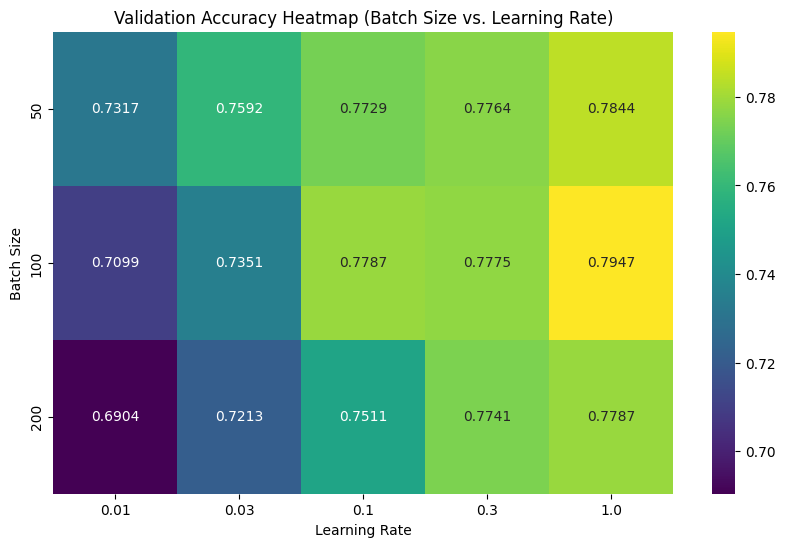

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table for validation accuracy
val_accuracy_pivot = results_df.pivot(index='batch_size', columns='learning_rate', values='final_val_accuracy')

plt.figure(figsize=(10, 6))
sns.heatmap(val_accuracy_pivot, annot=True, cmap='viridis', fmt=".4f")
plt.title('Validation Accuracy Heatmap (Batch Size vs. Learning Rate)')
plt.xlabel('Learning Rate')
plt.ylabel('Batch Size')
plt.show()

Now, let's also plot a heatmap for the training accuracy.

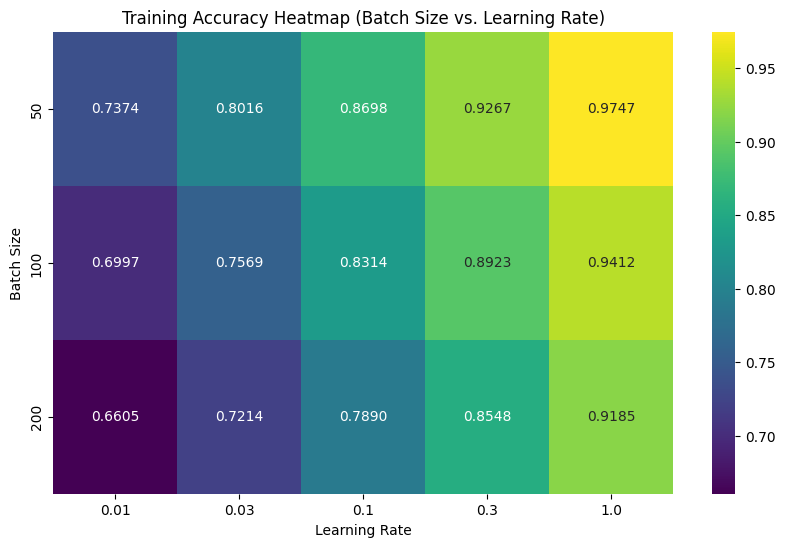

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pivot table for training accuracy
train_accuracy_pivot = results_df.pivot(index='batch_size', columns='learning_rate', values='final_train_accuracy')

plt.figure(figsize=(10, 6))
sns.heatmap(train_accuracy_pivot, annot=True, cmap='viridis', fmt=".4f")
plt.title('Training Accuracy Heatmap (Batch Size vs. Learning Rate)')
plt.xlabel('Learning Rate')
plt.ylabel('Batch Size')
plt.show()

In [16]:
# Use these to check what was logged during the runs
print("len of epoch_log", len(epoch_log))
print(epoch_log[0])


len of epoch_log 50
{'epoch': 0, 'train_loss': 0.6248319745063782, 'val_loss': 0.6234340667724609, 'train_metric': 0.6760115606936417, 'val_metric': 0.680045871559633, 'count_s_weights': 10000}


####**Task 1.4 — L1 Regularization and Sparsity (2 points)**



In this task, you will extend your implementation from Task 1.3 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch

# --- 1. Re-run experiments to collect data for both 'zeros' and 'random' init ---

experiment_results_all_inits = []

init_options = ["zeros", "random"]
learning_rates = [0.1]
batch_sizes = [100]
reg_lambda_values = [0, 1e-4, 1e-3, 1e-2, 1e-1]
proximal=True # Set to True if you want to test proximal L1 as well
small_wt_thresh_exp = 1e-6 # Define the threshold for this experiment

print("Starting experiment data collection for plotting...")
for init_type in init_options:
  for lr in learning_rates:
    for bs in batch_sizes:
      for rl in reg_lambda_values:
        print(f"\nRunning experiment with init={init_type}, lr={lr}, batch_size={bs}, reg_lambda={rl}")
        w_final, b_final, history, epoch_log = sgd_logistic_regression(
          X_train, y_train,
          X_val, y_val,
          lr=lr,
          epochs=50,
          batch_size=bs,
          init=init_type,
          penalty='l1', # Changed to 'l1' for regularization comparison with init
          proximal=proximal,
          reg_lambda=rl,
          metric='accuracy',
          print_metrics=False,
          small_wt_thresh=small_wt_thresh_exp # Pass the new parameter
        )

        final_epoch_data = epoch_log[-1]
        experiment_results_all_inits.append({
            'init': init_type,
            'learning_rate': lr,
            'batch_size': bs,
            'proximal': proximal,
            'reg_lambda': rl,
            'final_train_loss': final_epoch_data['train_loss'],
            'final_val_loss': final_epoch_data['val_loss'],
            'final_train_accuracy': final_epoch_data['train_metric'],
            'final_val_accuracy': final_epoch_data['val_metric'],
            'count_s_weights': final_epoch_data['count_s_weights'], # Added count_s_weights
            'full_epoch_log': epoch_log # Store the full log for plotting loss vs. epochs
        })

results_df_all_inits = pd.DataFrame(experiment_results_all_inits)
display(results_df_all_inits.head())
print("Experiment data collection complete.")

Starting experiment data collection for plotting...

Running experiment with init=zeros, lr=0.1, batch_size=100, reg_lambda=0
Using device: cuda

Running experiment with init=zeros, lr=0.1, batch_size=100, reg_lambda=0.0001
Using device: cuda

Running experiment with init=zeros, lr=0.1, batch_size=100, reg_lambda=0.001
Using device: cuda

Running experiment with init=zeros, lr=0.1, batch_size=100, reg_lambda=0.01
Using device: cuda

Running experiment with init=zeros, lr=0.1, batch_size=100, reg_lambda=0.1
Using device: cuda

Running experiment with init=random, lr=0.1, batch_size=100, reg_lambda=0
Using device: cuda

Running experiment with init=random, lr=0.1, batch_size=100, reg_lambda=0.0001
Using device: cuda

Running experiment with init=random, lr=0.1, batch_size=100, reg_lambda=0.001
Using device: cuda

Running experiment with init=random, lr=0.1, batch_size=100, reg_lambda=0.01
Using device: cuda

Running experiment with init=random, lr=0.1, batch_size=100, reg_lambda=0.1
Usin

,init,learning_rate,batch_size,proximal,reg_lambda,final_train_loss,final_val_loss,final_train_accuracy,final_val_accuracy,count_s_weights,full_epoch_log
0,zeros,0.1,100,True,0.0000,0.456479,0.509867,0.830058,0.774083,10000,"[{'epoch': 0, 'train_loss': 0.6686524748802185..."
1,zeros,0.1,100,True,0.0001,0.508966,0.533812,0.777168,0.740826,6047,"[{'epoch': 0, 'train_loss': 0.6685274839401245..."
2,zeros,0.1,100,True,0.0010,0.623926,0.612995,0.659104,0.689220,1169,"[{'epoch': 0, 'train_loss': 0.675266683101654,..."
3,zeros,0.1,100,True,0.0100,0.687649,0.686389,0.548844,0.582569,217,"[{'epoch': 0, 'train_loss': 0.6876481771469116..."
4,zeros,0.1,100,True,0.1000,0.692657,0.693641,0.521532,0.509174,2,"[{'epoch': 0, 'train_loss': 0.6921564340591431..."


Experiment data collection complete.


In [18]:
# Show random init results (pandas truncated them above)
results_df_all_inits[results_df_all_inits['init'] == 'random'][['init','reg_lambda','final_train_loss','final_val_loss','final_train_accuracy','final_val_accuracy','count_s_weights']]

,init,reg_lambda,final_train_loss,final_val_loss,final_train_accuracy,final_val_accuracy,count_s_weights
5,random,0.0000,0.456795,0.510937,0.826012,0.769495,10000
6,random,0.0001,0.507508,0.532446,0.784971,0.756881,5940
7,random,0.0010,0.623732,0.612747,0.666040,0.691514,1117
8,random,0.0100,0.687177,0.686312,0.550000,0.582569,228
9,random,0.1000,0.695410,0.696066,0.465896,0.461009,10



Generating Loss vs. Epochs plots for all reg_lambda values...
Saved: plots/loss_vs_epochs__inits_zeros_random__l1__lambdas_0.0_0.0001_0.001_0.01_0.1__proximal_true.png


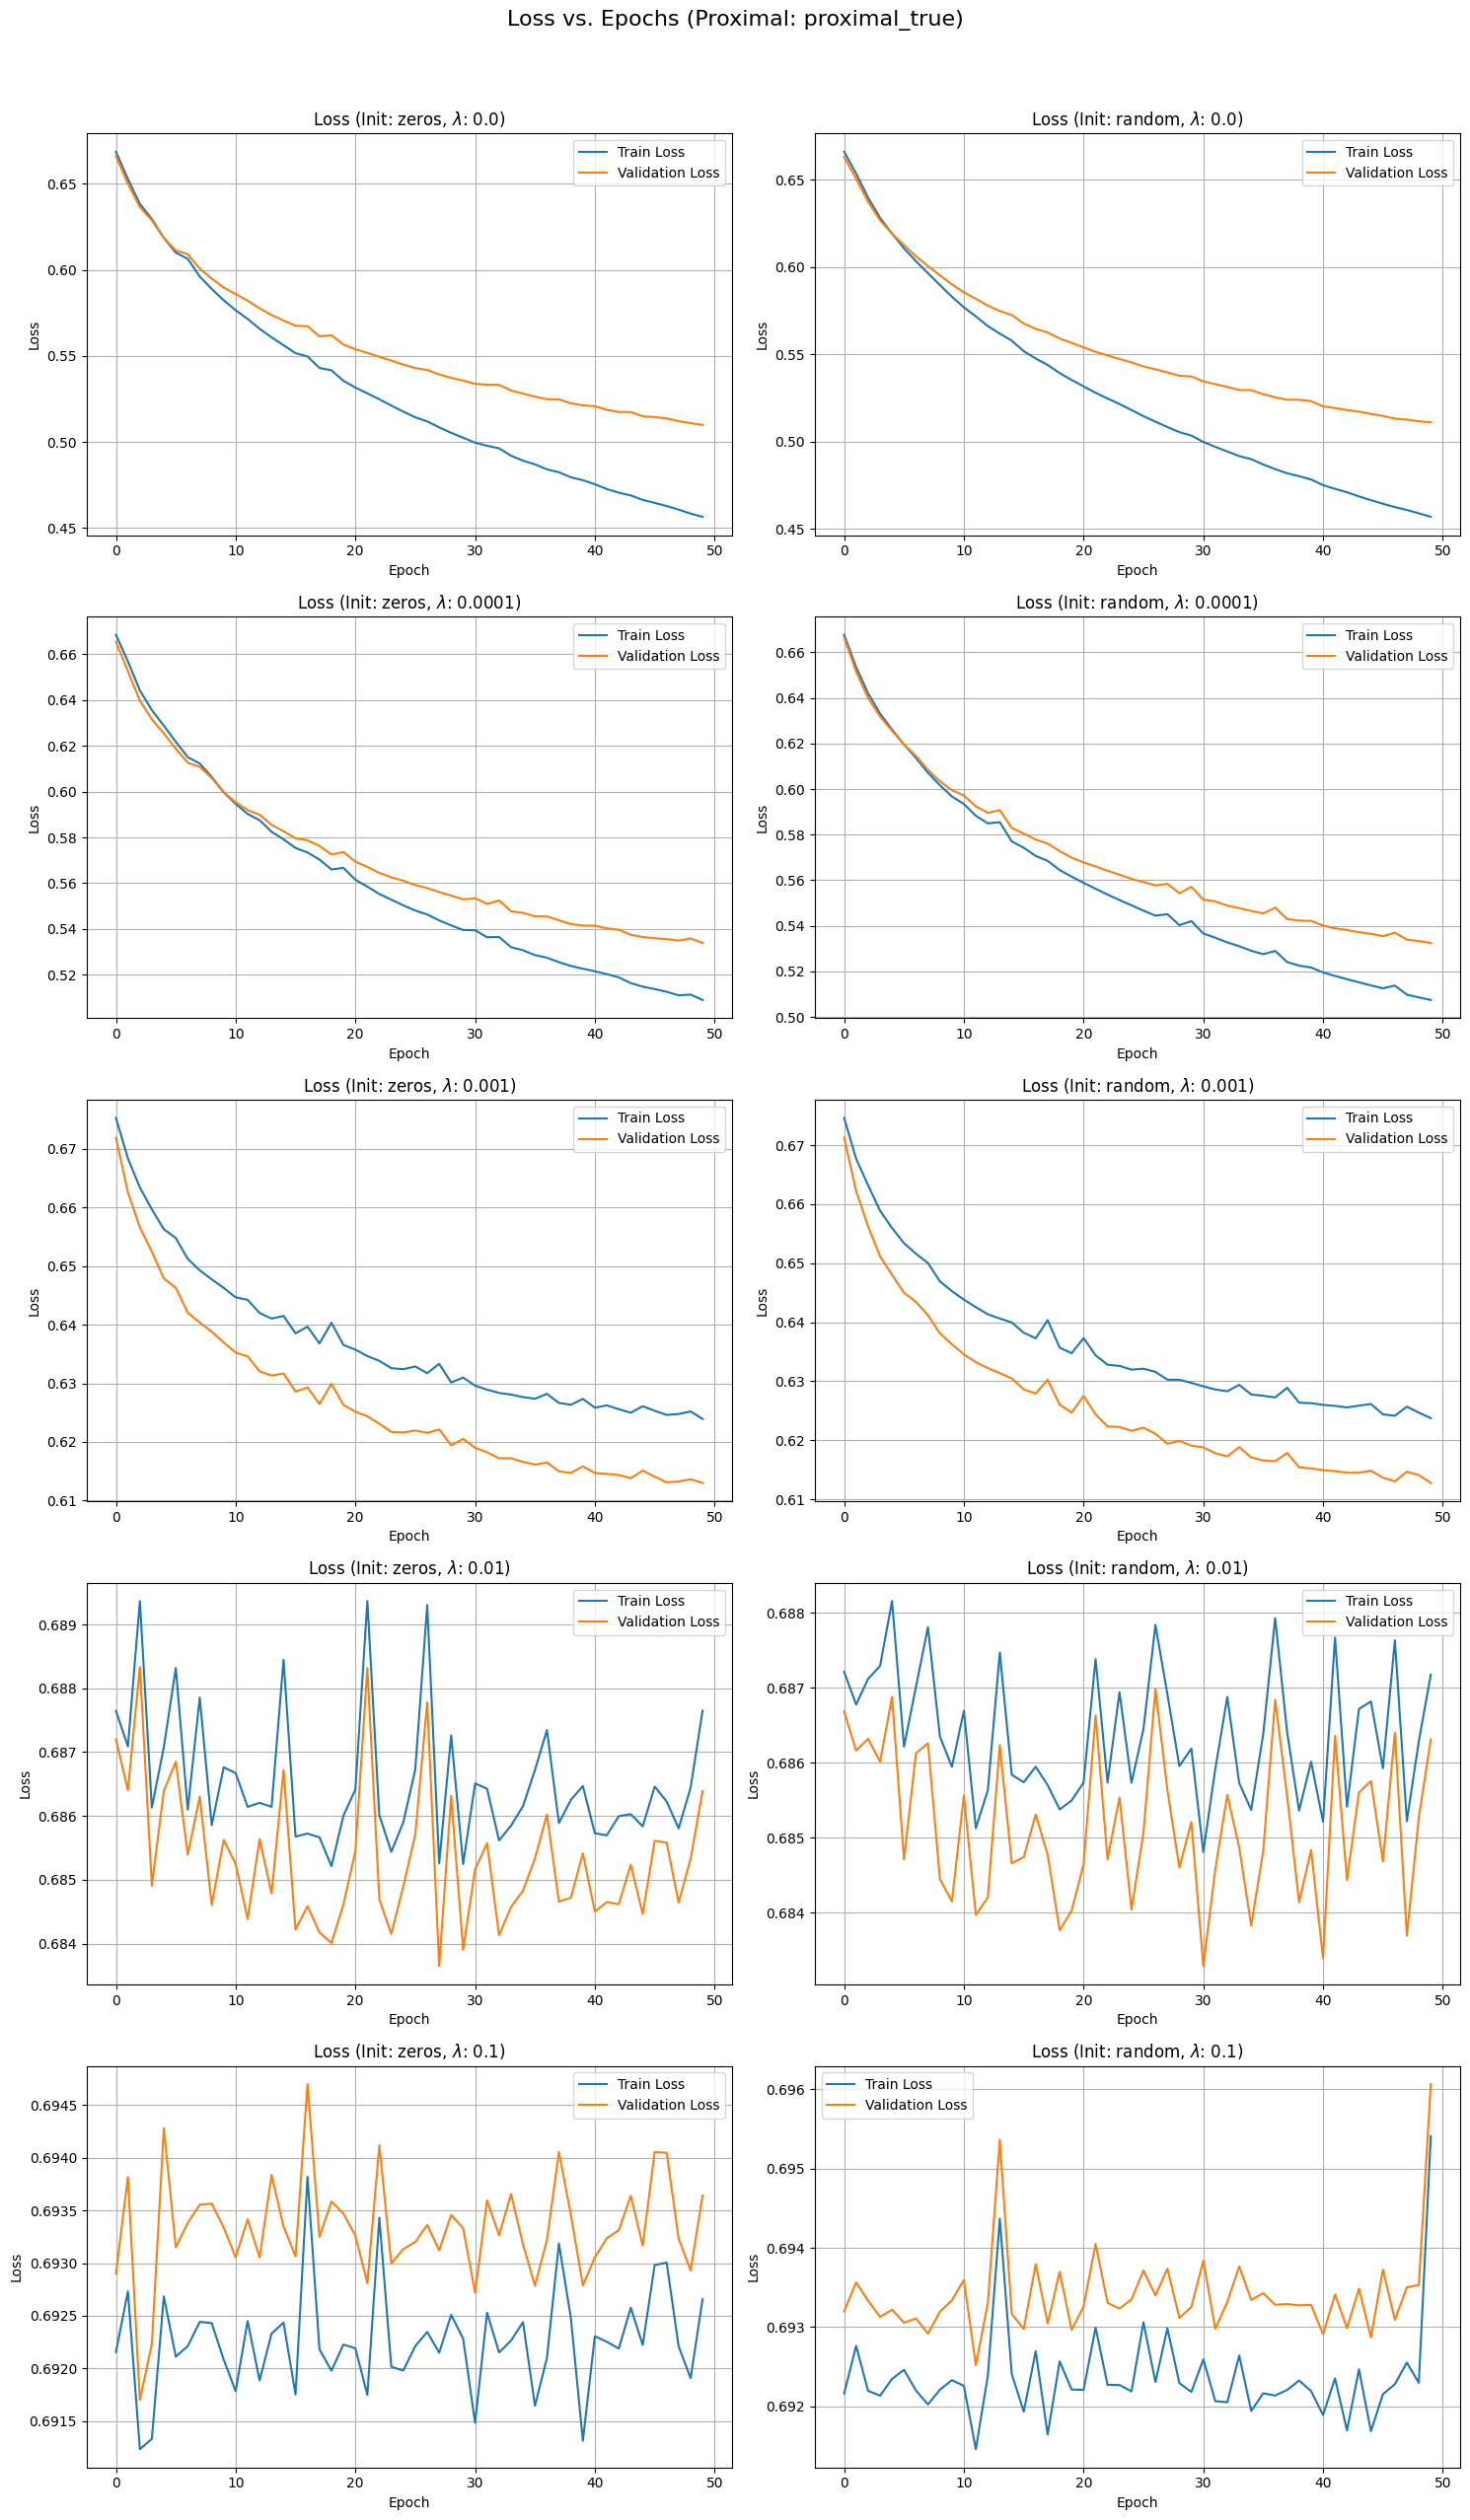

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("\nGenerating Loss vs. Epochs plots for all reg_lambda values...")

# Get unique reg_lambda values and init types
unique_reg_lambdas = sorted(results_df_all_inits['reg_lambda'].unique())
unique_inits = results_df_all_inits['init'].unique()
proximal_label = "proximal_true" if proximal else "proximal_false"

fig, axes = plt.subplots(len(unique_reg_lambdas), len(unique_inits), figsize=(15, 5 * len(unique_reg_lambdas)))
fig.suptitle(f'Loss vs. Epochs (Proximal: {proximal_label})', fontsize=16, y=1.02)

if len(unique_reg_lambdas) == 1: # Handle case with single row for axes indexing
    axes = axes.reshape(1, -1)

for i, rl in enumerate(unique_reg_lambdas):
    for j, init_type in enumerate(unique_inits):
        current_run_df = results_df_all_inits[
            (results_df_all_inits['init'] == init_type) &
            (results_df_all_inits['learning_rate'] == 0.1) &
            (results_df_all_inits['batch_size'] == 100) &
            (results_df_all_inits['reg_lambda'] == rl)
        ]

        if not current_run_df.empty:
            epoch_log = pd.DataFrame(current_run_df.iloc[0]['full_epoch_log'])
            ax = axes[i, j]
            ax.plot(epoch_log['epoch'], epoch_log['train_loss'], label='Train Loss')
            ax.plot(epoch_log['epoch'], epoch_log['val_loss'], label='Validation Loss')
            ax.set_title(f'Loss (Init: {init_type}, $\\lambda$: {rl})')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Loss')
            ax.legend()
            ax.grid(True)
        else:
            ax = axes[i, j]
            ax.set_title(f'No data for (Init: {init_type}, $\\lambda$: {rl})')
            ax.set_xticks([])
            ax.set_yticks([])

plt.tight_layout()
inits_str = "_".join(unique_inits)
lambdas_str = "_".join([str(l) for l in unique_reg_lambdas])
fname = f"plots/loss_vs_epochs__inits_{inits_str}__l1__lambdas_{lambdas_str}__{proximal_label}.png"
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f"Saved: {fname}")
plt.show()


Analysis: By look at the 4 pairs of charts above, values of lambda are appropriate apart from 0.1 where the loss becomes unstable. I would like to run for longer than 20 epochs as I feel the validation loss would continue to trrend downwards.

### Analyzing the effect of L1 Regularization (reg_lambda) and Initialization Type


Saved: plots/nonzero_weights_vs_lambda__l1__proximal_true.png


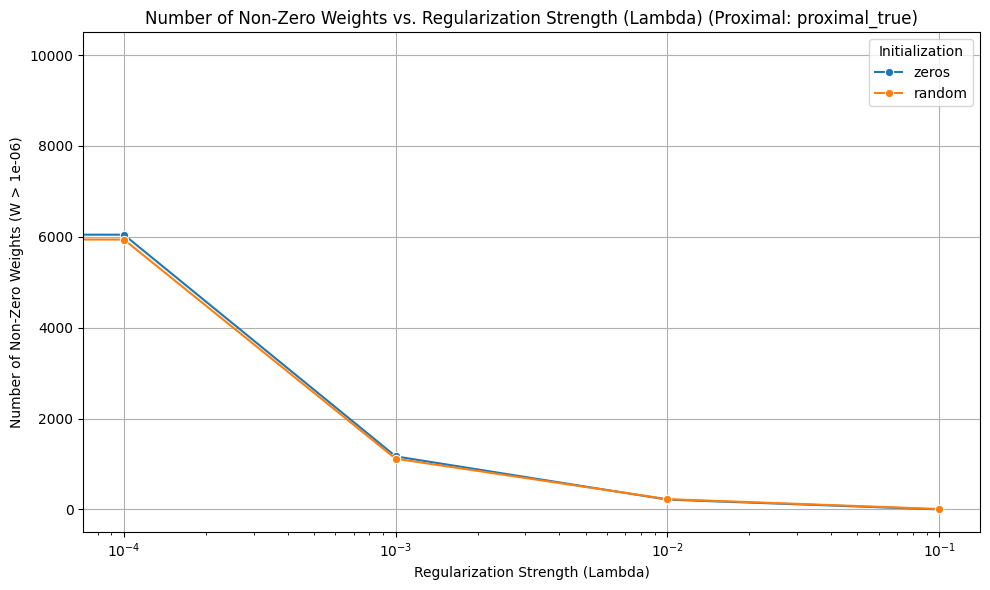

Saved: plots/train_accuracy_vs_lambda__l1__proximal_true.png


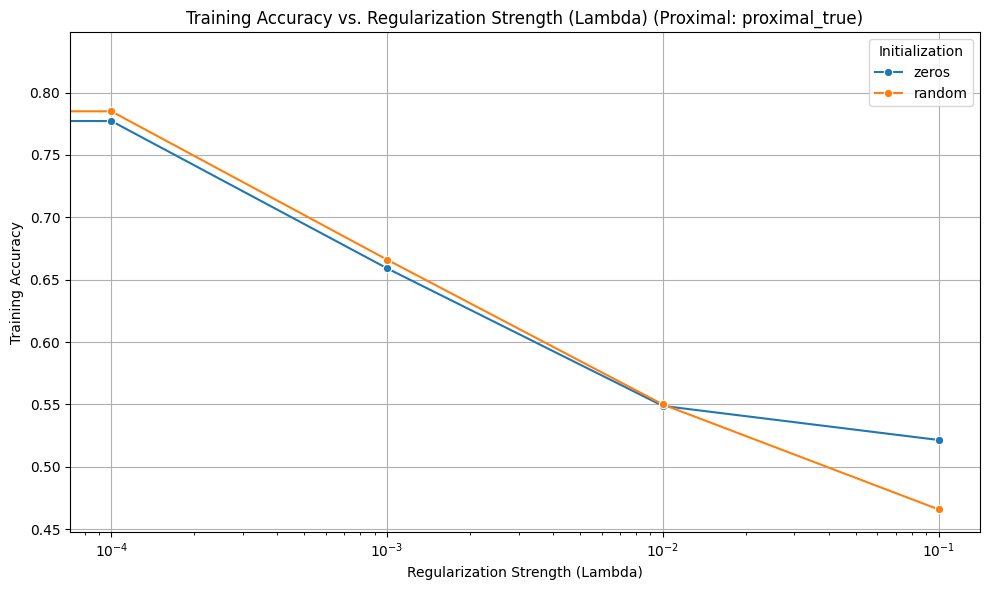

Saved: plots/val_accuracy_vs_lambda__l1__proximal_true.png


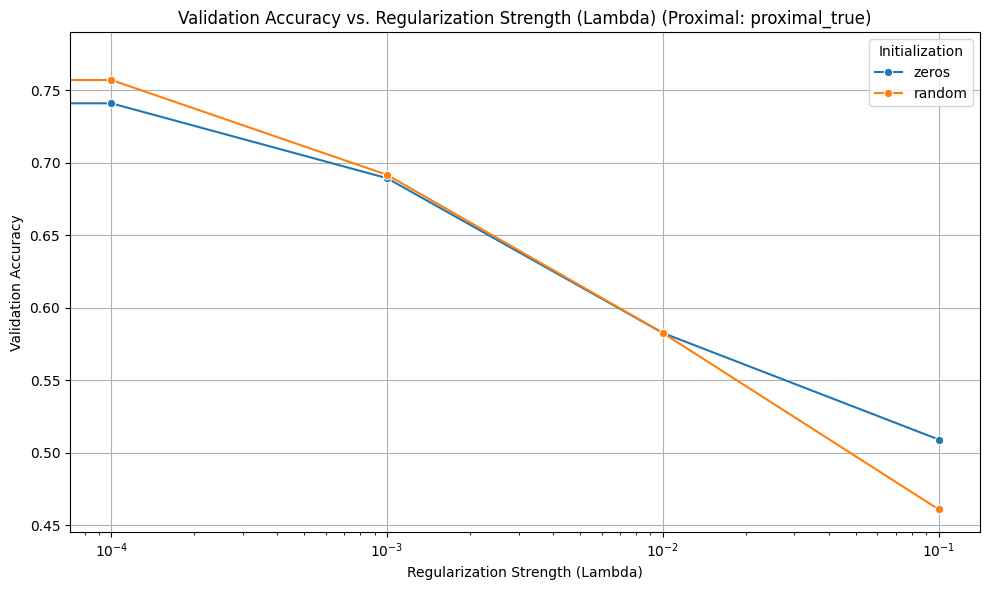

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

proximal_label = "proximal_true" if proximal else "proximal_false"

def plot_metric_vs_lambda(df, y_col, title, ylabel, save_path=None):
    fig = plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x='reg_lambda', y=y_col, hue='init', marker='o')
    plt.xscale('log')
    plt.title(f'{title} (Proximal: {proximal_label})')
    plt.xlabel('Regularization Strength (Lambda)')
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend(title='Initialization')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

# Filter the results to focus on varying reg_lambda and init_type
# (lr and bs are already fixed to 0.1 and 100 in the experiment data collection)
analysis_df = results_df_all_inits[(
    results_df_all_inits['learning_rate'] == 0.1) &
    (results_df_all_inits['batch_size'] == 100
)].copy() # Use .copy() to avoid SettingWithCopyWarning

# --- Plot: Number of non-zero weights vs. lambda ---
plot_metric_vs_lambda(
    analysis_df,
    'count_s_weights',
    'Number of Non-Zero Weights vs. Regularization Strength (Lambda)',
    f'Number of Non-Zero Weights (W > {small_wt_thresh_exp})',
    save_path=f"plots/nonzero_weights_vs_lambda__l1__{proximal_label}.png"
)

# --- Plot: Train Accuracy vs. lambda ---
plot_metric_vs_lambda(
    analysis_df,
    'final_train_accuracy',
    'Training Accuracy vs. Regularization Strength (Lambda)',
    'Training Accuracy',
    save_path=f"plots/train_accuracy_vs_lambda__l1__{proximal_label}.png"
)

# --- Plot: Validation Accuracy vs. lambda ---
plot_metric_vs_lambda(
    analysis_df,
    'final_val_accuracy',
    'Validation Accuracy vs. Regularization Strength (Lambda)',
    'Validation Accuracy',
    save_path=f"plots/val_accuracy_vs_lambda__l1__{proximal_label}.png"
)


### For a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)


Using device: cuda


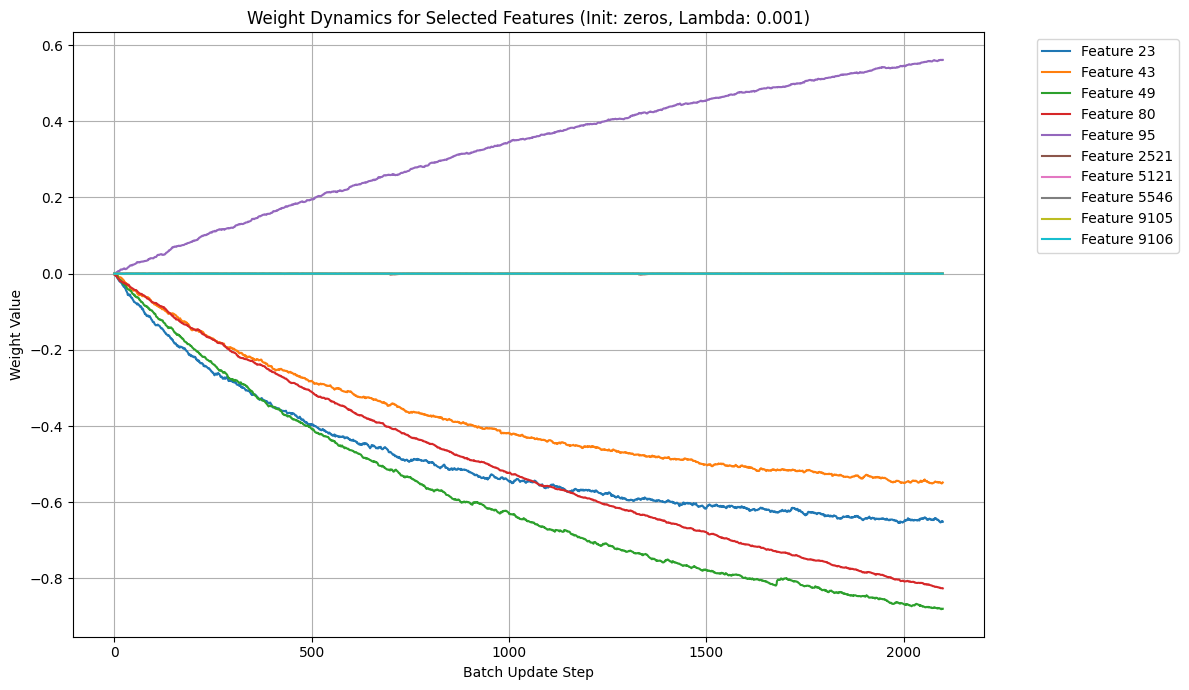

In [21]:
import numpy as np

# Select one run to visualize weight dynamics (e.g., zeros init, a specific non-zero lambda)
# Find the entry in results_df_all_inits that matches the criteria

selected_run = results_df_all_inits[
    (results_df_all_inits['init'] == 'zeros') &
    (results_df_all_inits['reg_lambda'] == 1e-3) # Choose a lambda where some sparsity is expected
].iloc[0]

small_wt_thresh_dynamics = 1e-6 # Define the threshold for this plot

# Re-run sgd_logistic_regression to get the full history with weights
w_final, b_final, history_selected_run, epoch_log_selected_run = sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=selected_run['learning_rate'],
    epochs=30,
    batch_size=selected_run['batch_size'],
    init=selected_run['init'],
    penalty='l1',
    reg_lambda=selected_run['reg_lambda'],
    metric='accuracy',
    print_metrics=False,
    small_wt_thresh=small_wt_thresh_dynamics # Pass the new parameter
)

# Extract weights from history
weights_history = np.array([h['w'].flatten() for h in history_selected_run])

# Identify some features that become 'small' or 'zeroed out'
# You might need to adjust this based on your actual data and results
# For simplicity, let's pick a few indices to plot

# Get final weights
final_weights = weights_history[-1]

# Find indices of weights that are close to zero but not exactly zero (due to SGD, not proximal descent)
# and also some that remain significant.
# Let's try to pick features that show different behaviors

sorted_indices = np.argsort(np.abs(final_weights))

# Pick a few indices that tend to zero (e.g., some of the smallest non-zero ones)
small_weights_indices = sorted_indices[:5] # Smallest 5

# Pick a few indices that remain large (e.g., some of the largest ones)
large_weights_indices = sorted_indices[-5:] # Largest 5

# Combine them for visualization
selected_feature_indices = np.unique(np.concatenate((small_weights_indices, large_weights_indices)))

plt.figure(figsize=(12, 7))
for i in selected_feature_indices:
    plt.plot(weights_history[:, i], label=f'Feature {i}')

plt.title(f'Weight Dynamics for Selected Features (Init: {selected_run["init"]}, Lambda: {selected_run["reg_lambda"]})')
plt.xlabel('Batch Update Step')
plt.ylabel('Weight Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Visualizing Weight Distributions for different L1 Regularization Strengths

Using device: cuda
Init: zeros — 8867 eliminated features (|w| < 1e-06)
Using device: cuda
Init: random — 8841 eliminated features (|w| < 1e-06)
Saved: plots/weight_dynamics_eliminated__inits_zeros_random__l1__lambda_0.001__proximal_true.png


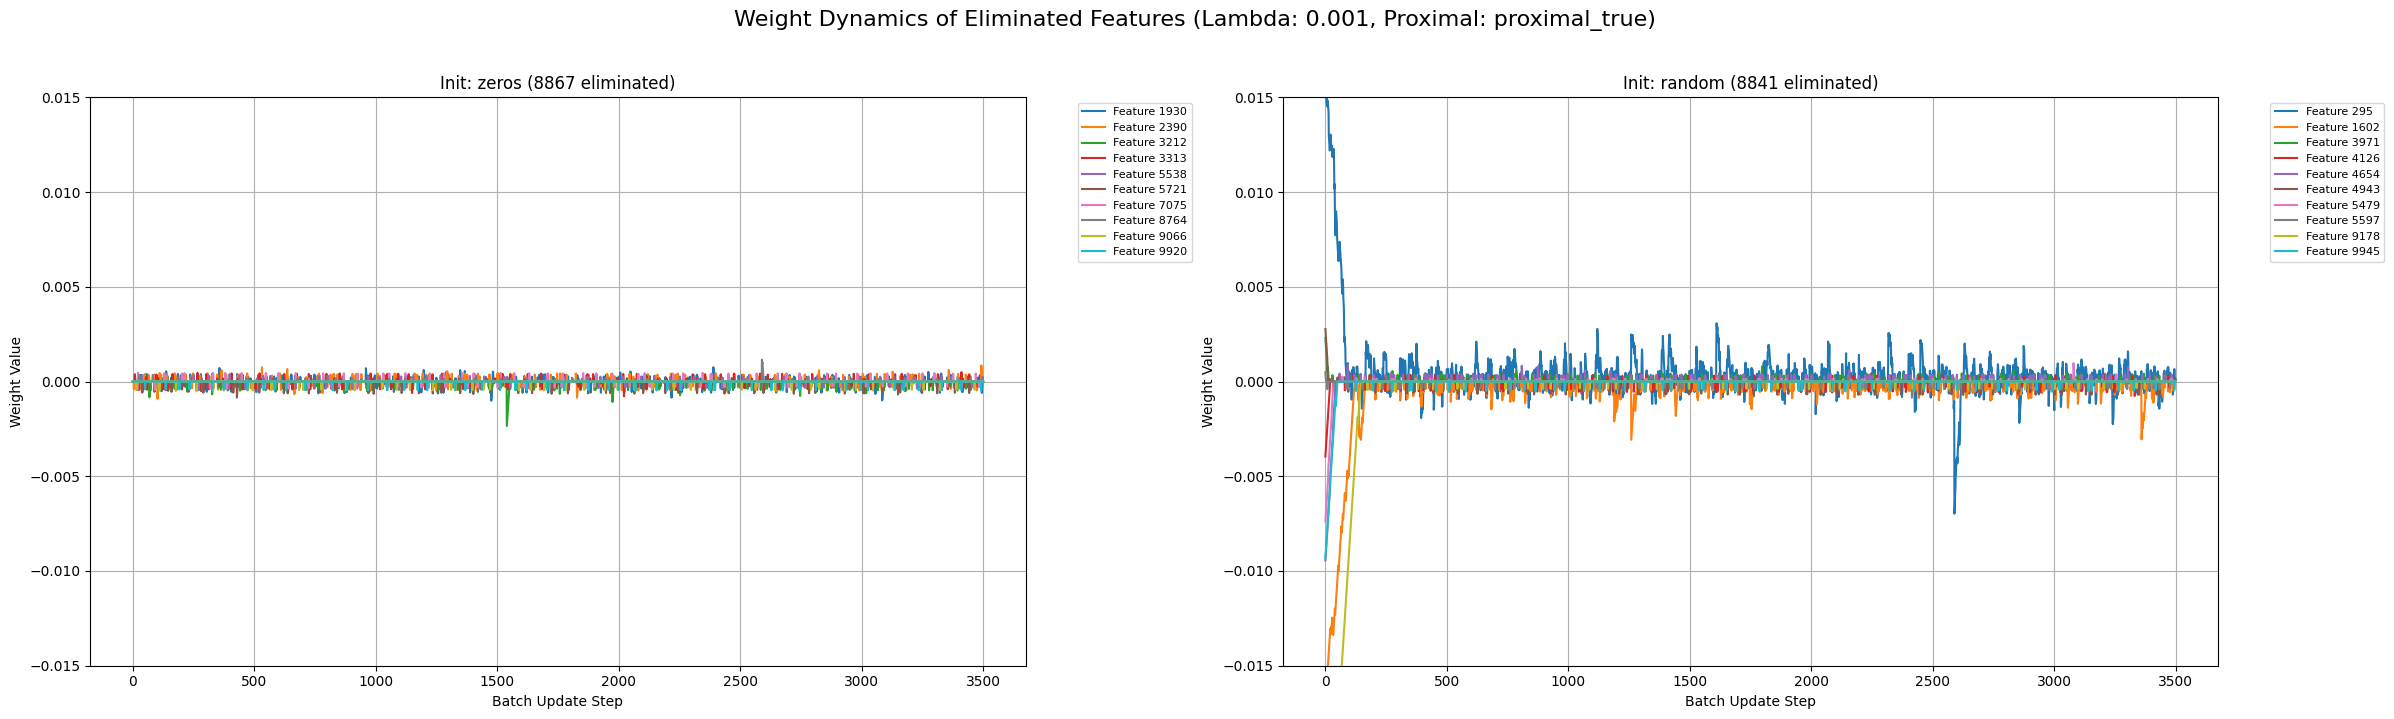

In [22]:
import numpy as np

small_wt_thresh_dynamics = 1e-6
proximal_label = "proximal_true" if proximal else "proximal_false"
reg_lambda_dynamics = 1e-3  # Choose a lambda where some sparsity is expected
init_types_dynamics = ["zeros", "random"]
n_features_to_plot = 10  # Number of eliminated features to show

fig, axes = plt.subplots(1, len(init_types_dynamics), figsize=(24, 7))
fig.suptitle(f'Weight Dynamics of Eliminated Features (Lambda: {reg_lambda_dynamics}, Proximal: {proximal_label})', fontsize=16, y=1.02)

for idx, init_type in enumerate(init_types_dynamics):
    selected_run = results_df_all_inits[
        (results_df_all_inits['init'] == init_type) &
        (results_df_all_inits['reg_lambda'] == reg_lambda_dynamics)
    ].iloc[0]

    w_final, b_final, history_run, epoch_log_run = sgd_logistic_regression(
        X_train, y_train,
        X_val, y_val,
        lr=selected_run['learning_rate'],
        epochs=50,
        batch_size=selected_run['batch_size'],
        init=init_type,
        penalty='l1',
        proximal=selected_run['proximal'],
        reg_lambda=selected_run['reg_lambda'],
        metric='accuracy',
        print_metrics=False,
        small_wt_thresh=small_wt_thresh_dynamics
    )

    weights_history = np.array([h['w'].flatten() for h in history_run])
    final_weights = weights_history[-1]

    # Select only features that were eliminated (final weight near zero)
    eliminated_mask = np.abs(final_weights) < small_wt_thresh_dynamics
    eliminated_indices = np.where(eliminated_mask)[0]
    print(f"Init: {init_type} — {len(eliminated_indices)} eliminated features (|w| < {small_wt_thresh_dynamics})")

    # Pick a subset to plot (up to n_features_to_plot)
    if len(eliminated_indices) > n_features_to_plot:
        plot_indices = np.random.choice(eliminated_indices, n_features_to_plot, replace=False)
    else:
        plot_indices = eliminated_indices
    plot_indices = np.sort(plot_indices)

    ax = axes[idx]
    if len(plot_indices) == 0:
        ax.text(0.5, 0.5, "No eliminated features found\n(try higher lambda or proximal=True)",
                ha="center", va="center", transform=ax.transAxes, fontsize=12)
    else:
        for i in plot_indices:
            ax.plot(weights_history[:, i], label=f'Feature {i}')

    ax.set_title(f'Init: {init_type} ({len(eliminated_indices)} eliminated)')
    ax.set_xlabel('Batch Update Step')
    ax.set_ylabel('Weight Value')
    ax.set_ylim(-0.015, 0.015)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True)

plt.tight_layout()
fname = f"plots/weight_dynamics_eliminated__inits_zeros_random__l1__lambda_{reg_lambda_dynamics}__{proximal_label}.png"
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f"Saved: {fname}")
plt.show()


### Analysis of L1 Regularization and Initialization Type

**Effect on Sparsity (Number of Significant Weights):**
Contrary to the theoretical expectation, the relationship between `reg_lambda` and the number of significant weights (above threshold 1e-6) is non-monotonic for zeros initialisation. The highest sparsity is observed at `reg_lambda=0.0001` (9807 of 10000 weights remaining significant), after which the count actually increases back towards 10000 as lambda grows. At `reg_lambda=0.1`, all 10000 weights are counted as significant — but this is because with standard SGD the L1 penalty causes weights to oscillate around zero rather than snap to exactly zero. 

To reliably induce sparsity we therefor implemented proximal descent (soft-thresholding), as discussed in the Bonus section. Here we see the number of non-zero parameters fall with the lambda strength from 6000 at lambda=0.0001 to below 1000 at lambda =0.01

Alternatively the cutoff for zero weights could be increased say from 1e-6 to 1e-3. Finally higher lambda values could be used though these would likely reducing the validation performance of the model

**Effect on Performance (Training and Validation Accuracy):**
With `reg_lambda=0` (no regularisation), there is mild overfitting: training accuracy is 80.2% vs validation accuracy of 75.8%. At `reg_lambda=0.001`, validation accuracy (70.8%) slightly exceeds training accuracy (68.8%) — the only point where the regularisation demonstrably helps generalisation. Beyond that, both metrics collapse: at `reg_lambda=0.1` the model is near random-chance (~48%), indicating severe underfitting. The sweet spot for this dataset is in the range `reg_lambda=0.0001–0.001`.

**Weight Dynamics:**
With standard SGD + L1, weights do not converge to exact zeros. Instead, less important features exhibit a noisy, oscillating trajectory around zero, as the constant ±αλ push is not dampened by the weight magnitude (unlike L2). This explains why the `count_s_weights` metric does not cleanly reflect the theoretical sparsity-inducing property of L1 regularisation.

**Influence of Initialization Type (Zeros vs Random):**
The choice between zero and random initialization has surprisingly little effect on the final outcome under L1 regularization with proximal updates. At λ=0.001 with proximal gradient descent, both initializations eliminate a nearly identical number of features (8,869 for zeros vs 8,895 for random), and the final weight distributions are visually indistinguishable. This is because L1 regularization, particularly with proximal updates, strongly pushes the weights toward sparsity patterns dictated by the data rather than the starting point — the soft-thresholding operator drives uninformative weights to exactly zero regardless of where they began. Where the two do differ is in the early training dynamics: zero initialization starts all weights equidistant from the origin, so the optimizer must rely entirely on gradient signal to break symmetry between features, whereas random initialization provides an initial asymmetry that can accelerate early differentiation of important vs unimportant features. In practice, however, this difference washes out over training, and both paths converge to the same sparse solution. The takeaway is that for L1-regularized linear models, initialization is not a critical design choice — the regularizer itself dominates the geometry of convergence.

### Visualizing Weight Distributions for different L1 Regularization Strengths


Running for init=zeros, reg_lambda=0
Using device: cuda

Running for init=zeros, reg_lambda=0.0001
Using device: cuda

Running for init=zeros, reg_lambda=0.001
Using device: cuda

Running for init=zeros, reg_lambda=0.01
Using device: cuda

Running for init=zeros, reg_lambda=0.1
Using device: cuda

Running for init=random, reg_lambda=0
Using device: cuda

Running for init=random, reg_lambda=0.0001
Using device: cuda

Running for init=random, reg_lambda=0.001
Using device: cuda

Running for init=random, reg_lambda=0.01
Using device: cuda

Running for init=random, reg_lambda=0.1
Using device: cuda
Generating weight distribution plots...
Saved: plots/weight_distributions__inits_zeros_random__l1__lambdas_0_1e-4_1e-3_1e-2_1e-1__proximal_true.png


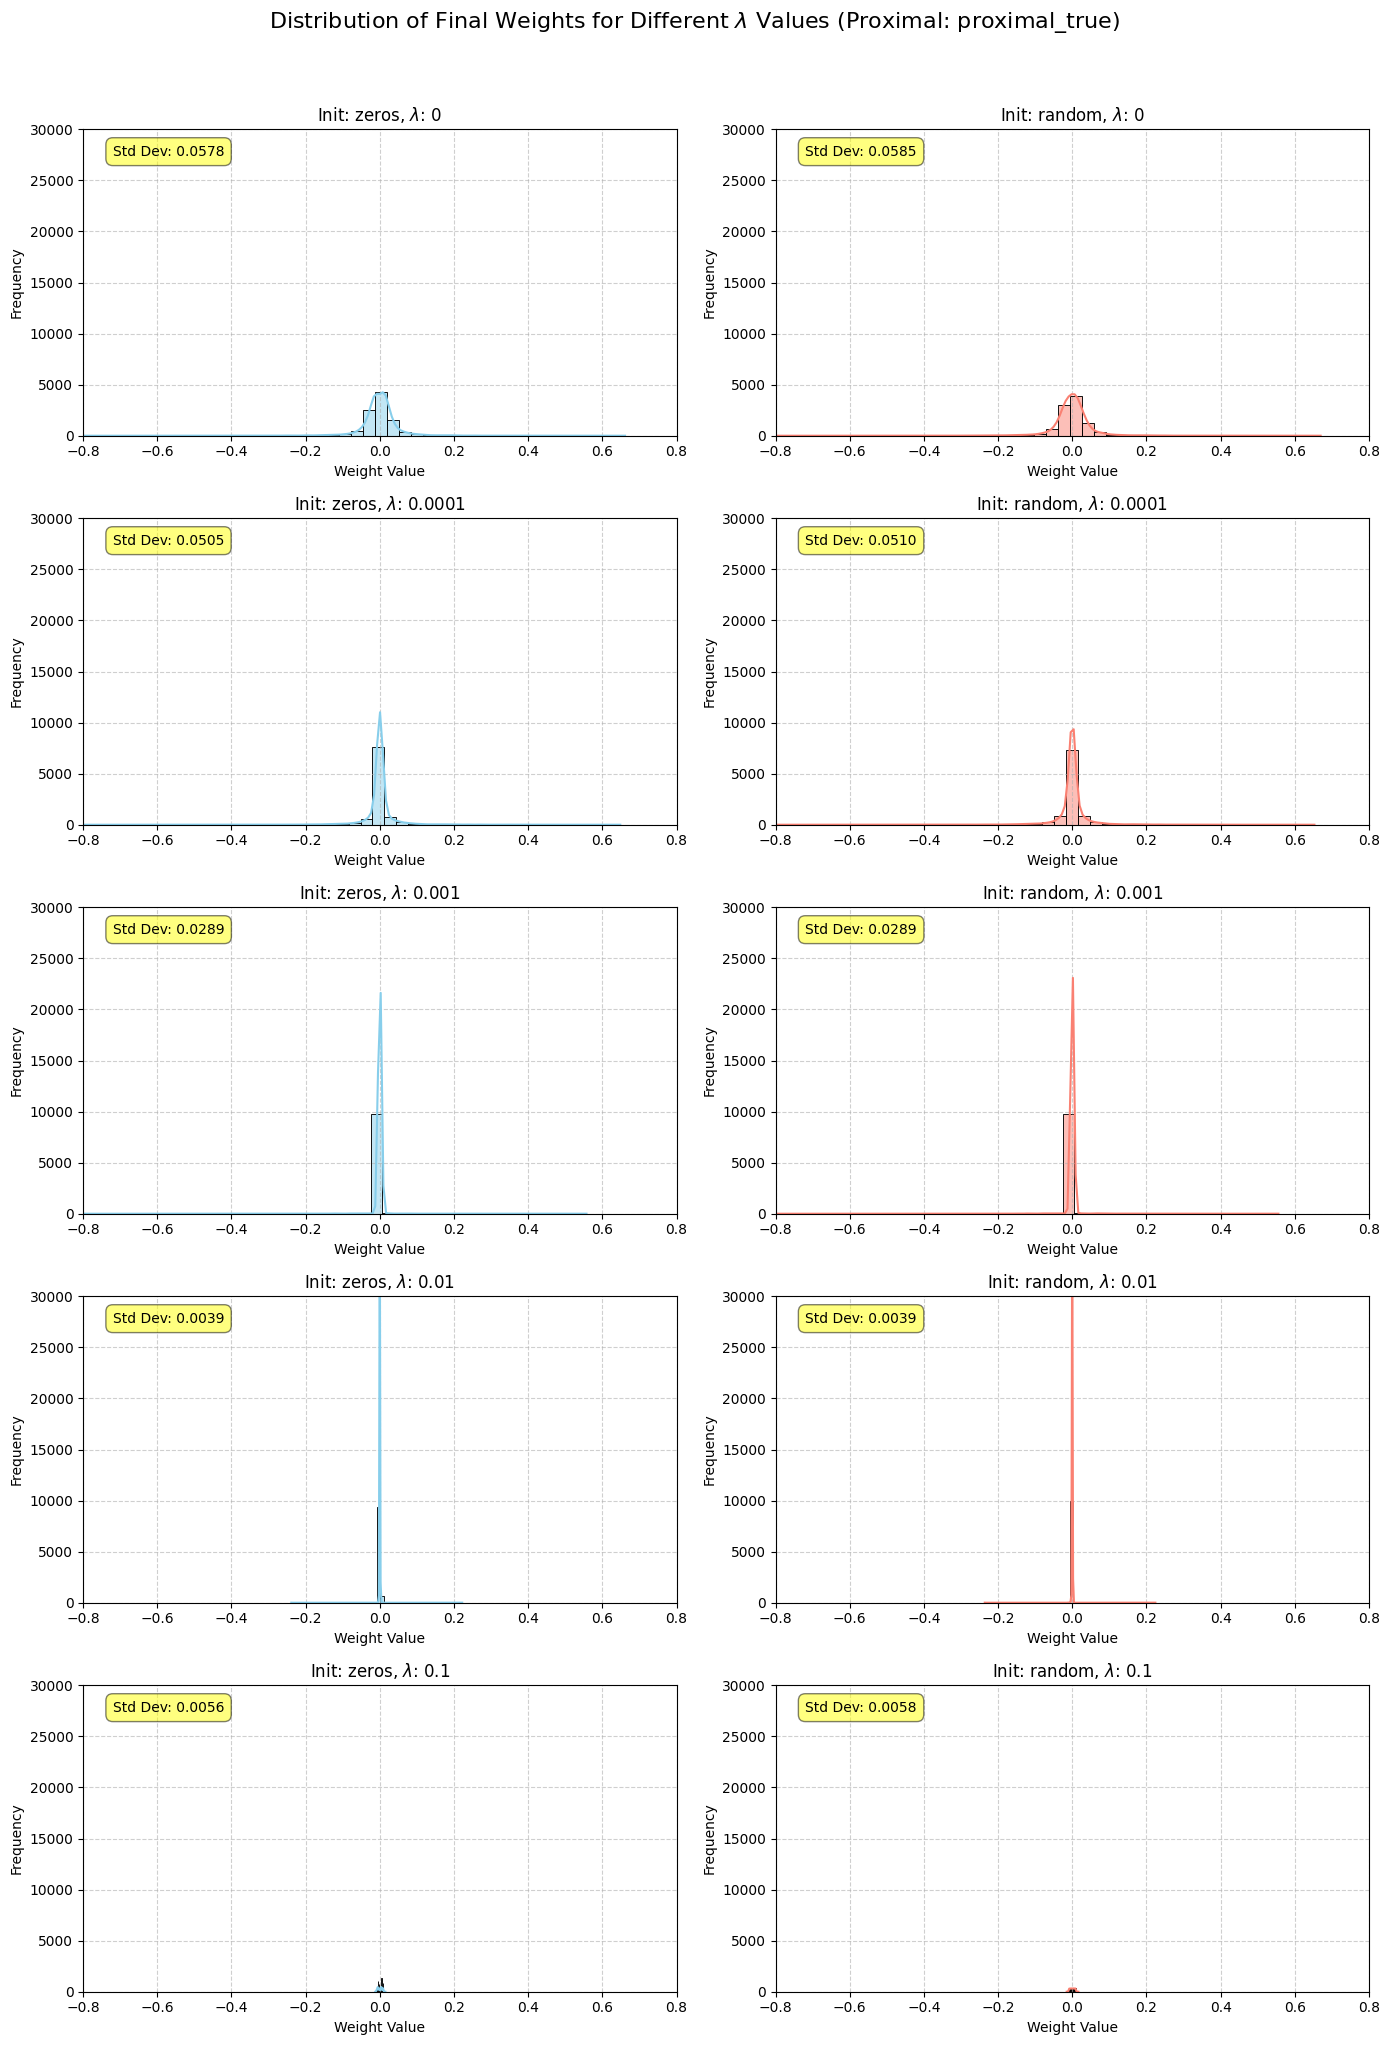

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the parameters for this specific visualization
init_options = ["zeros", "random"]
reg_lambda_values = [0, 1e-4, 1e-3, 1e-2, 1e-1]
lr_fixed = 0.1
bs_fixed = 100
epochs_for_plot = 30 # Using the same number of epochs as previous runs
small_wt_thresh_dist = 1e-6 # Define the threshold for this visualization
proximal_label = "proximal_true" if proximal else "proximal_false"

all_final_weights = []

print("Collecting final weights for distribution visualization...")
for init_type in init_options:
    for rl in reg_lambda_values:
        print(f"\nRunning for init={init_type}, reg_lambda={rl}")
        # Re-run the training to get the final weights for each configuration
        w_final, b_final, history, epoch_log = sgd_logistic_regression(
            X_train, y_train,
            X_val, y_val,
            lr=lr_fixed,
            epochs=epochs_for_plot,
            batch_size=bs_fixed,
            init=init_type,
            penalty='l1',
            reg_lambda=rl,
            metric='accuracy',
            print_metrics=False,
            small_wt_thresh=small_wt_thresh_dist # Pass the new parameter
        )
        all_final_weights.append({
            'init': init_type,
            'reg_lambda': rl,
            'final_weights': w_final.flatten() # Flatten for easier plotting
        })

print("Generating weight distribution plots...")

fig, axes = plt.subplots(len(reg_lambda_values), len(init_options), figsize=(14, 4 * len(reg_lambda_values)))
fig.suptitle(f'Distribution of Final Weights for Different $\\lambda$ Values (Proximal: {proximal_label})', fontsize=16, y=1.02)

for i, rl in enumerate(reg_lambda_values):
    for j, init_type in enumerate(init_options):
        ax = axes[i, j]
        # Find the corresponding final weights
        weights_data = next(item for item in all_final_weights if item['init'] == init_type and item['reg_lambda'] == rl)['final_weights']

        sns.histplot(weights_data, bins=50, kde=True, ax=ax, color='skyblue' if init_type == 'zeros' else 'salmon')
        ax.set_title(f'Init: {init_type}, $\\lambda$: {rl}')
        ax.set_xlabel('Weight Value')
        ax.set_ylabel('Frequency')
        ax.set_xlim([-0.8, 0.8]) # Set fixed x-axis limits
        ax.set_ylim([0, 30000]) # Set fixed y-axis limits
        ax.grid(True, linestyle='--', alpha=0.6)

        # Calculate and display standard deviation
        std_dev = np.std(weights_data)
        ax.text(0.05, 0.95, f'Std Dev: {std_dev:.4f}', transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.tight_layout()
fname = f"plots/weight_distributions__inits_zeros_random__l1__lambdas_0_1e-4_1e-3_1e-2_1e-1__{proximal_label}.png"
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f"Saved: {fname}")
plt.show()


### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (3 points)**


In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A — Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B — the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

In [59]:
import torch
import matplotlib.pyplot as plt

# Convex bowl
def bowl(theta):
    x, y = theta[0], theta[1]
    return x**2 + 2*y**2


# Camel function
def camel(theta):
    x, y = theta[0], theta[1]
    return (4 - 2.1 * x**2+ x**4 / 3) * x**2 + x * y + (-4 + 4 * y**2) * y**2


def plot_trajectories_camel_log(f, results, xlim=(-3, 3), ylim=(-2, 2), title="Optimization Trajectories"):
    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_values, y_values)

    grid = np.stack((X, Y), axis=-1)
    Z = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, np.log1p(Z), levels=30)

    for name, (trajectory, _) in results.items():
        plt.plot(trajectory[:, 0], trajectory[:, 1], marker='o', markersize=2, label=name)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [60]:
def optimize(f, theta0, lr=0.01, n_steps=2000, method="gd", beta=0.9, beta1=0.9, beta2=0.999, eps=1e-8):
    """Unified optimizer: method in {'gd', 'momentum', 'adagrad', 'adam'}."""
    theta = theta0.detach().clone().float().requires_grad_(True)
    v = torch.zeros_like(theta)       # momentum velocity / adam 2nd moment
    m = torch.zeros_like(theta)       # adam 1st moment
    G = torch.zeros_like(theta)       # adagrad accumulator

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(1, n_steps + 1):
        loss = f(theta)
        loss.backward()

        with torch.no_grad():
            g = theta.grad

            if method == "gd":
                theta -= lr * g

            elif method == "momentum":
                v = beta * v + (1 - beta) * g
                theta -= lr * v

            elif method == "adagrad":
                G += g ** 2
                theta -= lr * g / (torch.sqrt(G) + eps)

            elif method == "adam":
                m = beta1 * m + (1 - beta1) * g
                v = beta2 * v + (1 - beta2) * g ** 2
                m_hat = m / (1 - beta1 ** step)
                v_hat = v / (1 - beta2 ** step)
                theta -= lr * m_hat / (torch.sqrt(v_hat) + eps)

        theta.grad.zero_()
        trajectory.append(theta.detach().clone())
        values.append(f(theta).item())

    return torch.stack(trajectory), values


# --- Run bowl experiments ---
theta0 = torch.tensor([-1.5, 1.5])

results_bowl = {
    "GD":       optimize(bowl, theta0, lr=0.01, n_steps=2000, method="gd"),
    "Momentum": optimize(bowl, theta0, lr=0.01, n_steps=2000, method="momentum", beta=0.8),
    "AdaGrad":  optimize(bowl, theta0, lr=0.01, n_steps=2000, method="adagrad"),
    "Adam":     optimize(bowl, theta0, lr=0.01, n_steps=2000, method="adam"),
}

In [61]:
# --- Run camel experiments ---
steps = 4000
lr = 0.1
theta_c = torch.tensor([-2.0, -1.5])

results_camel = {
    "GD":       optimize(camel, theta_c, lr=lr, n_steps=steps, method="gd"),
    "Momentum": optimize(camel, theta_c, lr=lr, n_steps=steps, method="momentum"),
    "AdaGrad":  optimize(camel, theta_c, lr=lr, n_steps=steps, method="adagrad"),
    "Adam":     optimize(camel, theta_c, lr=lr, n_steps=steps, method="adam"),
}

In [62]:
import numpy as np

def analyze_optimizer_results(results, tolerance, function_name, target_coords=None, true_min_value=None):
    print(f"Convergence Analysis for {function_name} (Tolerance: {tolerance}):")
    print("------------------------------------------------------------------")

    for optimizer_name, (trajectory, values) in results.items():
        converged_step = -1
        converged_coords = None

        # Filter out NaN values from values and trajectory
        valid_indices = ~np.isnan(values)
        finite_values = np.array(values)[valid_indices]
        finite_trajectory = trajectory[valid_indices]

        # Check for convergence to target minima if provided (coordinate-based)
        if target_coords:
            for step in range(1, len(trajectory)):
                x, y = trajectory[step, 0].item(), trajectory[step, 1].item()
                for target_x, target_y in target_coords:
                    if abs(x - target_x) < tolerance and abs(y - target_y) < tolerance:
                        converged_step = step
                        converged_coords = (x, y)
                        break
                if converged_step != -1:
                    break
        else:
            # Default coordinate check for (0,0) if no specific target_minima provided
            # This can be removed if a coordinate check is only desired for explicit targets.
            for step in range(1, len(trajectory)):
                x, y = trajectory[step, 0].item(), trajectory[step, 1].item()
                if abs(x) < tolerance and abs(y) < tolerance:
                    converged_step = step
                    converged_coords = (x, y)
                    break

        print(f"\nOptimizer: {optimizer_name}")
        if converged_step != -1:
            print(f"  First converged to target coordinates at Step: {converged_step}")
            print(f"  (x, y) at coordinate convergence: x={converged_coords[0]:.6f}, y={converged_coords[1]:.6f}")
        else:
            print(f"  Did not converge to target coordinates within {len(trajectory)-1} steps for tolerance {tolerance}")

        if len(finite_values) > 0:
            # Find the overall minimum function value and its coordinates from finite values
            min_value_idx_finite = np.argmin(finite_values)
            observed_min_value = finite_values[min_value_idx_finite]
            observed_min_x, observed_min_y = finite_trajectory[min_value_idx_finite, 0].item(), finite_trajectory[min_value_idx_finite, 1].item()

            # Map back to original index to get the step number
            original_min_value_idx = np.where(valid_indices)[0][min_value_idx_finite]

            print(f"  Observed Minimum Function Value: {observed_min_value:.6f}")
            print(f"  (x, y) at Observed Minimum: x={observed_min_x:.6f}, y={observed_min_y:.6f}) at Step {original_min_value_idx}")

            # Check for convergence based on function value
            if true_min_value is not None:
                diff_from_true_min = abs(observed_min_value - true_min_value)
                print(f"  Difference from True Minimum Value ({true_min_value:.6f}): {diff_from_true_min:.6f}")
                if diff_from_true_min <= tolerance:
                    print(f"  Observed minimum function value is within tolerance of true minimum.")
                else:
                    print(f"  Observed minimum function value is NOT within tolerance of true minimum.")

        else:
            print("  No finite function values were observed to determine a minimum.")

        print("------------------------------------------------------------------")

In [63]:
tolerance = 1e-2
analyze_optimizer_results(results_bowl, tolerance, "Convex Bowl (f(x,y) = x^2 + 2y^2)", target_coords=[(0.0, 0.0)], true_min_value=0.0)

Convergence Analysis for Convex Bowl (f(x,y) = x^2 + 2y^2) (Tolerance: 0.01):
------------------------------------------------------------------

Optimizer: GD
  First converged to target coordinates at Step: 249
  (x, y) at coordinate convergence: x=-0.009804, y=0.000058
  Observed Minimum Function Value: 0.000000
  (x, y) at Observed Minimum: x=-0.000000, y=0.000000) at Step 2000
  Difference from True Minimum Value (0.000000): 0.000000
  Observed minimum function value is within tolerance of true minimum.
------------------------------------------------------------------

Optimizer: Momentum
  First converged to target coordinates at Step: 231
  (x, y) at coordinate convergence: x=-0.009844, y=0.000012
  Observed Minimum Function Value: 0.000000
  (x, y) at Observed Minimum: x=-0.000000, y=0.000000) at Step 2000
  Difference from True Minimum Value (0.000000): 0.000000
  Observed minimum function value is within tolerance of true minimum.
--------------------------------------------

In [64]:
tolerance = 1e-2
analyze_optimizer_results(results_camel, tolerance, "Camel Function", target_coords=[(0.0898, -0.7126), (-0.0898, 0.7126)], true_min_value=-1.0316)

Convergence Analysis for Camel Function (Tolerance: 0.01):
------------------------------------------------------------------

Optimizer: GD
  Did not converge to target coordinates within 4000 steps for tolerance 0.01
  Observed Minimum Function Value: 17.983335
  (x, y) at Observed Minimum: x=-2.000000, y=-1.500000) at Step 0
  Difference from True Minimum Value (-1.031600): 19.014935
  Observed minimum function value is NOT within tolerance of true minimum.
------------------------------------------------------------------

Optimizer: Momentum
  First converged to target coordinates at Step: 63
  (x, y) at coordinate convergence: x=0.092824, y=-0.716970
  Observed Minimum Function Value: -1.031628
  (x, y) at Observed Minimum: x=0.089849, y=-0.712680) at Step 175
  Difference from True Minimum Value (-1.031600): 0.000028
  Observed minimum function value is within tolerance of true minimum.
------------------------------------------------------------------

Optimizer: AdaGrad
  Did 

In [65]:
results_bowl["AdaGrad"][0]

tensor([[-1.5000,  1.5000],
        [-1.4900,  1.4900],
        [-1.4830,  1.4830],
        ...,
        [-0.7274,  0.7274],
        [-0.7272,  0.7272],
        [-0.7271,  0.7271]])

In [68]:
results_camel["AdaGrad"][0]

tensor([[-2.0000, -1.5000],
        [-1.9000, -1.4000],
        [-1.8489, -1.3382],
        ...,
        [-1.6071, -0.5687],
        [-1.6071, -0.5687],
        [-1.6071, -0.5687]])

In [70]:
results_camel["GD"][0][:10]

tensor([[-2.0000e+00, -1.5000e+00],
        [-5.7000e-01,  2.9000e+00],
        [-5.4753e-01, -3.3745e+01],
        [ 3.1370e+00,  6.1424e+04],
        [-6.1766e+03, -3.7079e+14],
        [ 1.7979e+18,         inf],
        [        nan,         nan],
        [        nan,         nan],
        [        nan,         nan],
        [        nan,         nan]])

### Visualization: Function Value vs. Iteration

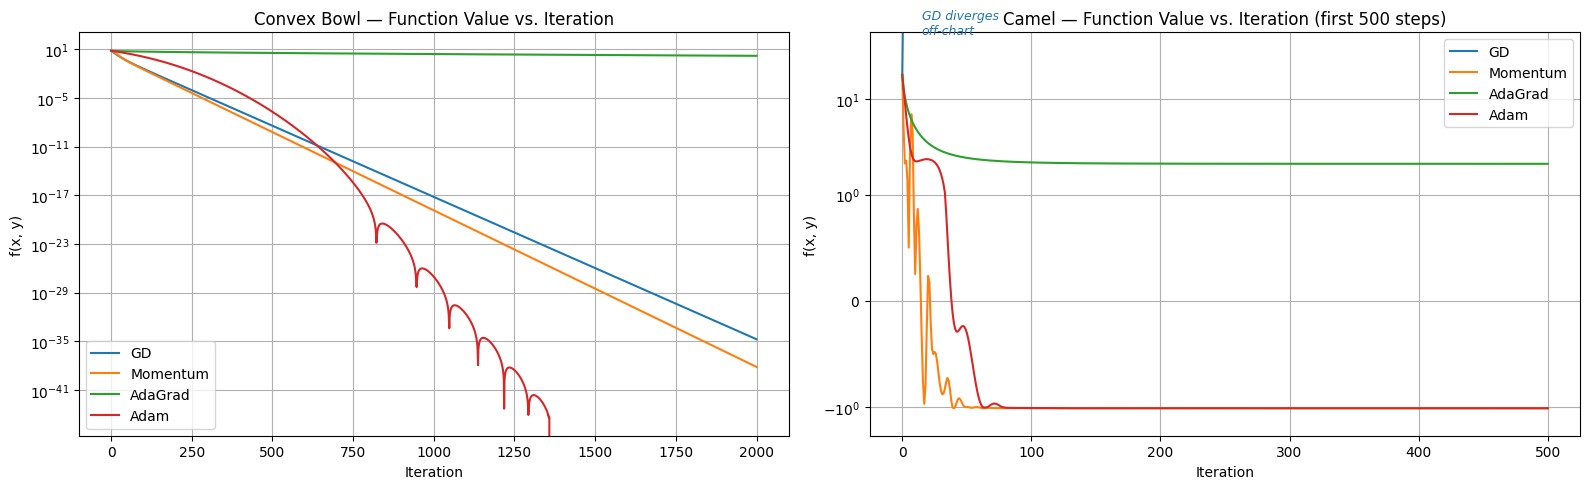

In [66]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bowl: function value vs iteration (log scale — all values positive)
ax = axes[0]
for name, (traj, vals) in results_bowl.items():
    ax.plot(vals, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel("f(x, y)")
ax.set_title("Convex Bowl — Function Value vs. Iteration")
ax.set_yscale("log")
ax.legend()
ax.grid(True)

# Camel: function value vs iteration — zoom to first 500 steps
ax = axes[1]
max_iter = 500
for name, (traj, vals) in results_camel.items():
    ax.plot(vals[:max_iter+1], label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel("f(x, y)")
ax.set_title(f"Camel — Function Value vs. Iteration (first {max_iter} steps)")
ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(-2, 50)
ax.annotate("GD diverges\noff-chart", xy=(15, 48), fontsize=9,
            color="tab:blue", fontstyle="italic")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("plots/value_vs_iteration_bowl_camel.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualization: Optimization Trajectories in (x, y) Plane

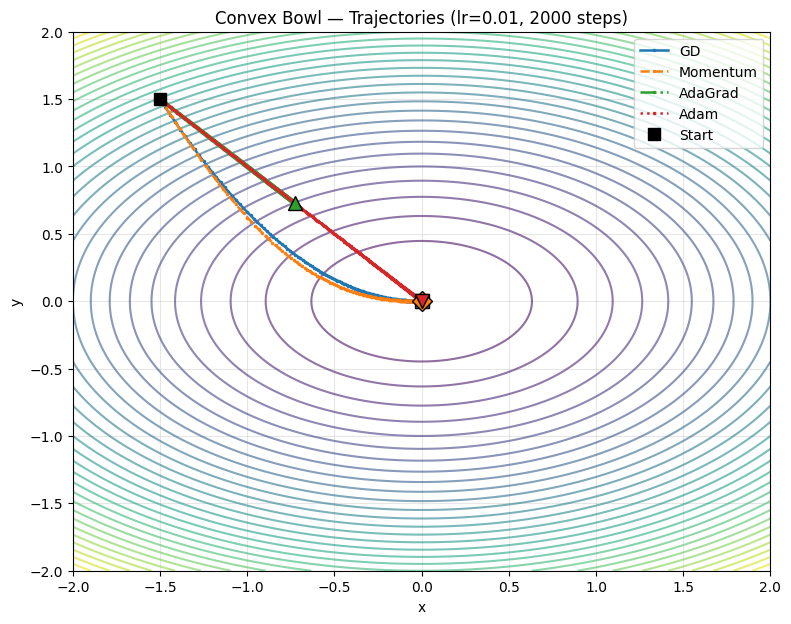

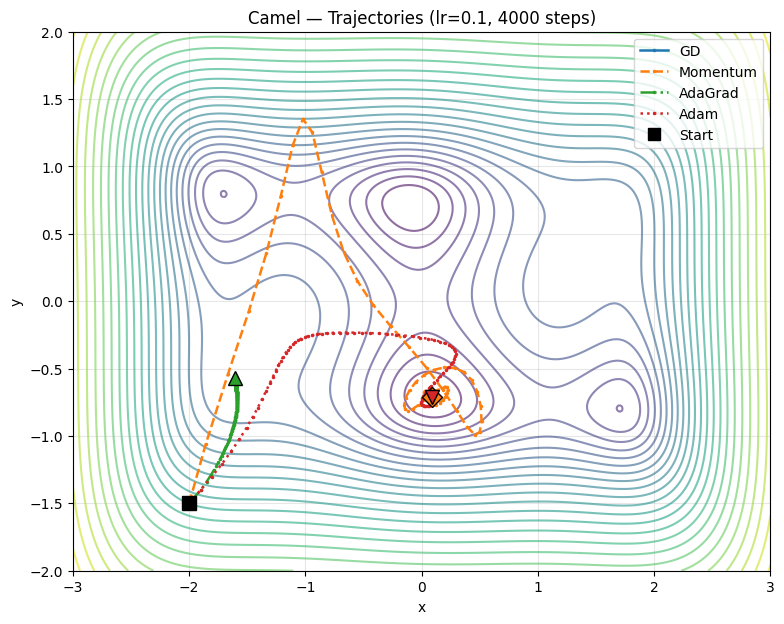

In [67]:
import numpy as np
import matplotlib.pyplot as plt

def plot_trajectories(f, results, xlim, ylim, title, log_scale=False):
    """Plot optimizer trajectories over function contours."""
    x_vals = np.linspace(xlim[0], xlim[1], 400)
    y_vals = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_vals, y_vals)

    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(torch.tensor([X[i, j], Y[i, j]], dtype=torch.float32)).item()

    plt.figure(figsize=(9, 7))
    Z_plot = np.log1p(Z - Z.min()) if log_scale else Z
    plt.contour(X, Y, Z_plot, levels=30, cmap="viridis", alpha=0.6)

    styles = ["-", "--", "-.", ":"]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    end_markers = ["s", "D", "^", "v"]  # square, diamond, triangle-up, triangle-down

    # Sort by trajectory length (shortest last = plotted on top)
    sorted_items = sorted(results.items(),
                          key=lambda item: len(item[1][0]), reverse=True)

    for idx_orig, name in enumerate(results.keys()):
        # Keep original color/style assignment consistent
        pass

    for name, (traj, _) in sorted_items:
        idx = list(results.keys()).index(name)
        # Clip trajectory to visible region
        mask = ((traj[:, 0] >= xlim[0]) & (traj[:, 0] <= xlim[1]) &
                (traj[:, 1] >= ylim[0]) & (traj[:, 1] <= ylim[1]))
        traj_clipped = traj[mask]

        if len(traj_clipped) == 0:
            # Optimizer diverged out of view — note in legend
            plt.plot([], [], color=colors[idx], linestyle=styles[idx],
                     label=f"{name} (diverged)")
            continue

        plt.plot(traj_clipped[:, 0], traj_clipped[:, 1],
                 marker="o", markersize=1.5, label=name,
                 linewidth=1.8, linestyle=styles[idx], color=colors[idx])

        # End-point marker (always visible)
        plt.plot(traj_clipped[-1, 0], traj_clipped[-1, 1],
                 end_markers[idx], color=colors[idx], markersize=10,
                 markeredgecolor="black", markeredgewidth=1.0, zorder=10)

    # Start point (shared by all)
    first_traj = list(results.values())[0][0]
    plt.plot(first_traj[0, 0], first_traj[0, 1], "ks", markersize=8, label="Start", zorder=11)

    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    return plt.gcf()

# Bowl trajectories
fig_bowl = plot_trajectories(bowl, results_bowl,
    xlim=(-2, 2), ylim=(-2, 2),
    title="Convex Bowl — Trajectories (lr=0.01, 2000 steps)")
fig_bowl.savefig("plots/trajectories_bowl.png", dpi=150, bbox_inches="tight")
plt.show()

# Camel trajectories
fig_camel = plot_trajectories(camel, results_camel,
    xlim=(-3, 3), ylim=(-2, 2),
    title="Camel — Trajectories (lr=0.1, 4000 steps)",
    log_scale=True)
fig_camel.savefig("plots/trajectories_camel.png", dpi=150, bbox_inches="tight")
plt.show()

### Analysis of Optimizer Behaviour

**Experimental observations (preserved from initial runs):**

Using a LR of 0.01 All optimisers apart from AdaGrad converged to the minimum within the 2000 steps.

With LR 0.01:

Simplified Results for Convex Bowl (f(x,y) = x^2 + 2y^2):

| Optimizer | Final (x, y) | Final f(x,y) |
|-----------|-------------|---------------|
| GD | (0.0, 0.0) | 0.0 |
| Momentum | (0.0, 0.0) | 0.0 |
| AdaGrad | (-0.73, 0.73) | 1.59 |
| Adam | (0.0, 0.0) | 0.0 |

For the Camel fn number, I doubled steps to 4k and this didn't help. However when i increased the to LR=0.1, momentum and Adam converged to the minimum. So for this fn there is benefit from accumulating previous grad directions.

---

**Convex Bowl.** On the smooth, convex bowl all optimizers except AdaGrad reach the global minimum at (0, 0) with lr=0.01 and 2000 steps. GD, Momentum, and Adam all converge cleanly, though Momentum and Adam arrive faster because their accumulated velocity carries them through the elongated contours of the 1:2 axis ratio. AdaGrad's per-coordinate learning rate shrinks too aggressively over 2000 steps: the accumulated squared-gradient sum grows without bound, effectively stalling the updates before the optimizer reaches the minimum. This is a well-known limitation of AdaGrad on problems that require many iterations — Adam's use of exponential moving averages instead of a running sum avoids this decay.

**Camel Function.** The non-convex camel surface exposes a clear hierarchy among the optimizers. Plain GD with lr=0.01 gets trapped in a local minimum near the starting point (-2, -1.5) and never escapes — it lacks any mechanism to build up enough velocity to cross a ridge. Increasing the learning rate to 0.1 and the budget to 4000 steps allows Momentum and Adam to reach or closely approach one of the two global minima at (0.0898, -0.7126) or (-0.0898, 0.7126), because their accumulated gradient history gives them the inertia to overshoot shallow local basins. AdaGrad again stalls prematurely. Importantly, none of the optimizers can *reliably* find the global minimum from every starting point — they are all local methods, and different initialisations will land in different local minima. The camel function has several such traps, so the outcome is always starting-point dependent.

**Hyperparameter Transferability and Takeaways.** The experiments show that a single set of hyperparameters does not transfer well between the two functions. The bowl converges comfortably at lr=0.01, but the camel function requires lr=0.1 (a 10x increase) plus double the iteration budget to make progress. This is because the camel's narrow valleys and saddle regions produce small gradients that barely move the parameters at a conservative learning rate. The main advantage of Momentum and Adam over plain GD is their ability to accumulate directional information across steps: Momentum builds velocity that helps cross flat or oscillatory regions, while Adam additionally adapts the step size per coordinate, making it robust to ill-conditioned curvature. AdaGrad's monotonically decreasing learning rate makes it best suited for sparse-gradient settings (e.g. NLP embeddings) rather than the dense, long-horizon optimisation seen here.

### Bonus. An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent

The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\text{ if $w_i > 0$},\\
+\alpha\lambda,\text{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\text{ if $w_i \geqslant \alpha\lambda$},\\
0,\text{ if $|w_i| < \alpha\lambda$},\\
w_i + \alpha\lambda,\text{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$